In [1]:
import json
import pandas as pd
import numpy as np
from random import randrange
from matplotlib import pyplot as plt
import seaborn as sns

Il seguente notebook viene usato solo per dare uno sguardo alla variabili presenti nel dataset, non verranno modificate ne rimosse

In primo luogo analizziamo le variabili che non costituisco la griglia.

In [2]:
#C:/Users/Francesco/Documents/uni/tesi/data_expl_analysis
#C:/Users/fra24/OneDrive/Documenti/uni/magistrale/tesi/data/problems_2016.json
df = pd.read_csv('C:/Users/Francesco/Documents/uni/tesi/data_expl_analysis/moonboard_2016_engeneered.csv', encoding='utf-8')
df.iloc[:,0:9].head(10)
df.shape

(59506, 448)

In [3]:
from sklearn.model_selection import train_test_split
df_stima, df_verifica = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
# Reset degli indici per praticità
df_stima = df_stima.reset_index(drop=True)
df_verifica = df_verifica.reset_index(drop=True)
print(f"Stima: {df_stima.shape}, Verifica: {df_verifica.shape}")
df_stima.head()

Stima: (47604, 448), Verifica: (11902, 448)


,name,grade,grade_v,userGrade,setby,method,userRating,repeats,isBenchmark,isMaster,...,n_clusters,mean_cluster_size,max_cluster_size,clusters_per_hold,max_density_3x3,bbox_h,bbox_w,aspect_ratio,switch_righe,switch_colonne
0,Cut/copy/paste,7A,V6,7A,other,Feet follow hands,5,3,False,False,...,6.0,1.000000,1.0,1.000000,2.0,9.0,9.0,1.000000,12.0,12.0
1,Big Love,6B+,V4,NaN,other,Feet follow hands,4,20,False,False,...,7.0,1.142857,2.0,0.875000,2.0,11.0,10.0,0.909091,14.0,14.0
2,mblack1,6B+,V4,NaN,other,Feet follow hands,4,8,False,False,...,8.0,1.250000,3.0,0.800000,3.0,10.0,10.0,1.000000,16.0,18.0
3,George 3,6B+,V4,6B+,other,Feet follow hands,3,5,False,False,...,8.0,1.000000,1.0,1.000000,2.0,9.0,11.0,1.222222,13.0,16.0
4,Jumbo Perch,7A+,V7,NaN,other,Feet follow hands,5,4,False,False,...,6.0,1.166667,2.0,0.857143,2.0,14.0,10.0,0.714286,12.0,12.0


In [4]:
df_stima.iloc[:,0:17].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47604 entries, 0 to 47603
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   name                   47604 non-null  object
 1   grade                  47604 non-null  object
 2   grade_v                47604 non-null  object
 3   userGrade              25191 non-null  object
 4   setby                  47604 non-null  object
 5   method                 47604 non-null  object
 6   userRating             47604 non-null  int64 
 7   repeats                47604 non-null  int64 
 8   isBenchmark            47604 non-null  bool  
 9   isMaster               47604 non-null  bool  
 10  upgraded               47604 non-null  bool  
 11  downgraded             47604 non-null  bool  
 12  holdsets               47604 non-null  object
 13  hasBetaVideo           47604 non-null  bool  
 14  apiId                  47604 non-null  int64 
 15  dateInserted       

In [5]:
df.iloc[:,0:17].describe().round(2)

,userRating,repeats,apiId,holdsetup.description
count,59506.00,59506.00,59506.00,59506.0
mean,3.40,51.94,347782.21,2016.0
std,1.72,638.87,95064.18,0.0
min,0.00,0.00,19215.00,2016.0
25%,3.00,1.00,320999.25,2016.0
50%,4.00,3.00,365410.50,2016.0
75%,4.00,10.00,415076.25,2016.0
max,5.00,44491.00,462581.00,2016.0


***VALORI MANCANTI:***

In [6]:
missing = df_stima.isna().sum()
missing_vars = missing[missing > 0]
print(missing_vars)

userGrade    22413
dtype: int64


***Analisi univariate***

**grade**, livello di difficoltà assegnato dal creatore.

       Frequenza relativa
grade                    
6B                 0.0001
6B+                0.3248
6C                 0.1240
6C+                0.1508
7A                 0.1341
7A+                0.1013
7B                 0.0476
7B+                0.0554
7C                 0.0351
7C+                0.0162
8A                 0.0067
8A+                0.0020
8B                 0.0009
8B+                0.0010


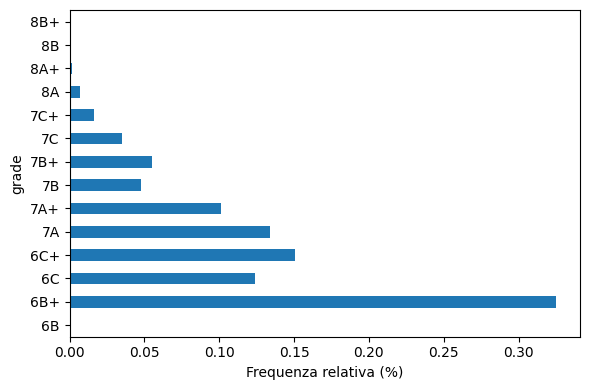

In [7]:
grade_order = ["6B", "6B+", "6C", "6C+", "7A", "7A+", "7B", "7B+", "7C", "7C+", "8A", "8A+", "8B", "8B+"]
grade_counts = df_stima["grade"].value_counts(normalize=True).reindex(grade_order)
print(grade_counts.round(4).to_frame("Frequenza relativa"))
plt.figure(figsize=(6, 4))
grade_counts.plot(kind="barh")
plt.xlabel('Frequenza relativa (%)')
plt.xlabel("Frequenza relativa (%)")
plt.tight_layout()
plt.show()

**userGrade**, livello di difficoltà assegnato dagli utenti. RIMUOVERE, VARIABILE CHE VIENE DOPO

<Axes: ylabel='userGrade'>

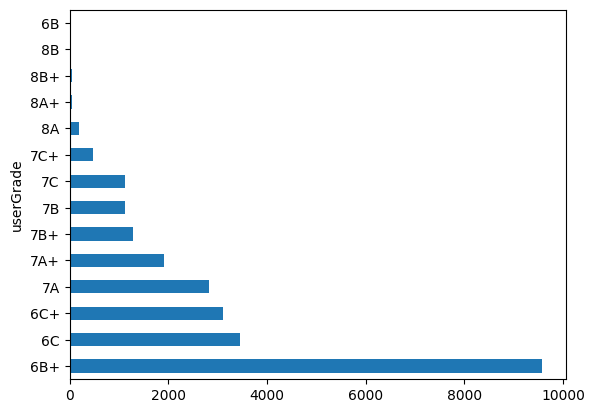

In [8]:
df_stima["userGrade"].value_counts().plot(kind="barh")

**userRating**, valutazione degli utenti del problema. RIMUOVERE, VARIABILE CHE VIENE DOPO

In [9]:
(df_stima["userRating"].value_counts() / df_stima.shape[0]).sort_index()

userRating
0    0.181938
1    0.011070
2    0.008697
3    0.070183
4    0.490526
5    0.237585
Name: count, dtype: float64

**repeats**, numero di volte che un problema è stato completato. RIMUOVERE, VARIABILE CHE VIENE DOPO

In [10]:
df_stima["repeats"].describe().round(3)

count    47604.000
mean        52.598
std        644.923
min          0.000
25%          1.000
50%          3.000
75%         10.000
max      44491.000
Name: repeats, dtype: float64

**isBenchmark**, indica se il problema è stato tracciato da Moonboard.

In [11]:
(df_stima["isBenchmark"].value_counts() / df_stima.shape[0]).round(4)

isBenchmark
False    0.9915
True     0.0085
Name: count, dtype: float64

**hasBetaVideo**, se il problema ha un video in cui si mostra la risoluzione. -> RIMOSSO, non inerente

isMaster, RIMUOVERE COSTANTE

In [12]:
(df_stima["isMaster"].value_counts() / df_stima.shape[0]) #da non usare

isMaster
False    1.0
Name: count, dtype: float64

method: RIMUOVERE, COSTANTE

In [13]:
(df_stima["method"].value_counts()/df_stima.shape[0]).round(4)#.plot(kind="barh")

method
Feet follow hands    1.0
Name: count, dtype: float64

**holdsets**, tipo di prese utilizzate per la tracciatura.


In [14]:
(df_stima["hasBetaVideo"].value_counts() / df_stima.shape[0])

hasBetaVideo
False    0.97662
True     0.02338
Name: count, dtype: float64

In [15]:
df_stima["holdsets"].value_counts() #molti dubbi su questa colonna

holdsets
Original School Holds | Hold Set A | Hold Set B    22957
Hold Set A | Hold Set B                            17242
Original School Holds | Hold Set A                  2074
Hold Set A                                          1622
Original School Holds | Hold Set B                  1545
Hold Set B                                          1247
Original School Holds                                917
Name: count, dtype: int64

**holdsetup.description**, anno della Moonboard e grado di inclinazione del problema. -> RIMOSSO, costante

<Axes: ylabel='holdsets'>

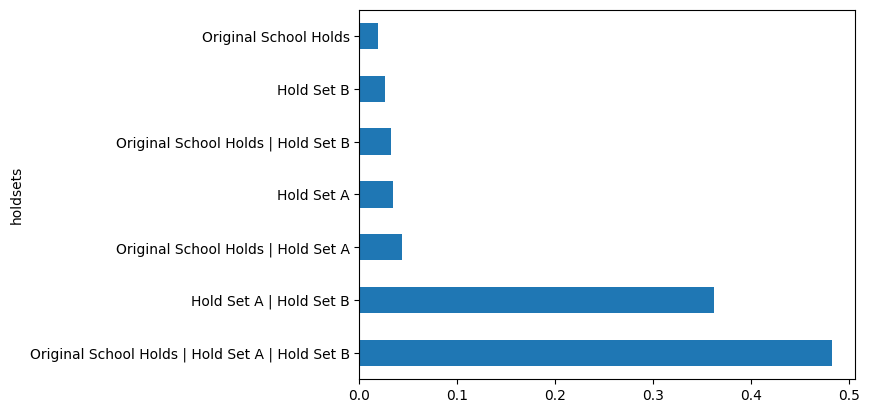

In [16]:
(df_stima["holdsets"].value_counts()/df_stima.shape[0]).plot(kind="barh")

**Variabili A1, A2, ..., K17, K18.**

In [17]:
(df_stima["holdsetup.description"].value_counts() / df_stima.shape[0])

holdsetup.description
2016    1.0
Name: count, dtype: float64

setby, RIMOSSO

In [18]:
df_stima["setby"].value_counts()

setby
other                  41880
Tonip                    594
Riccardo Caprasecca      476
MoonBoardSystem          392
Adan_vive                366
Patton                   327
DanielBar                312
Kilgour22                293
JAVIERMENG               283
Rodope                   282
Kyle Knapp               278
kisareitit               253
Resnick                  237
dopedick                 232
Gus Carter               230
Josh Ko                  212
Hakan Ertekin            212
Twan                     192
Hash Brown               186
cory galloway            185
Strato Sfera             182
Name: count, dtype: int64

upgraded, downgraded DA RIMUOVERE

RIMOZIONE VARIABILI:

In [139]:
df_stima.iloc[:,0:17].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47604 entries, 0 to 47603
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   name                   47604 non-null  object
 1   grade                  47604 non-null  object
 2   grade_v                47604 non-null  object
 3   userGrade              25191 non-null  object
 4   setby                  47604 non-null  object
 5   method                 47604 non-null  object
 6   userRating             47604 non-null  int64 
 7   repeats                47604 non-null  int64 
 8   isBenchmark            47604 non-null  bool  
 9   isMaster               47604 non-null  bool  
 10  upgraded               47604 non-null  bool  
 11  downgraded             47604 non-null  bool  
 12  holdsets               47604 non-null  object
 13  hasBetaVideo           47604 non-null  bool  
 14  apiId                  47604 non-null  int64 
 15  dateInserted       

In [140]:
columns_to_remove = ["name", "userGrade", "setby", 
                     "method", "userRating", "repeats",
                     "isMaster", "upgraded", "downgraded", 
                     "dateInserted", "hasBetaVideo", 
                     "holdsetup.description", "apiId"] 
df_stima_cleaned = df_stima.drop(columns=columns_to_remove)
df_verifica_cleaned = df_verifica.drop(columns=columns_to_remove)

print(f"Stima: {df_stima_cleaned.shape}, Verifica: {df_verifica_cleaned.shape}")

Stima: (47604, 435), Verifica: (11902, 435)


In [141]:
columns = df_stima.loc[:, "A1":"K18"].columns
result = df_stima[columns].apply(lambda col: col.value_counts() / df_stima.shape[0])

In [142]:
result.iloc[:, 0:5].round(3)

,A1,A2,A3,A4,A5
0,1.0,1.0,1.0,1.0,0.921
1,NaN,NaN,NaN,NaN,0.079


In [143]:
result.iloc[:, 193:198].round(3)

,K14,K15,K16,K17,K18
0,0.977,1.0,0.984,1.0,0.898
1,0.023,NaN,0.016,NaN,0.102


In [146]:
result

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,K9,K10,K11,K12,K13,K14,K15,K16,K17,K18
0,1.0,1.0,1.0,1.0,0.920826,0.999979,1.0,1.0,0.969204,0.989539,...,0.964709,0.984518,0.974162,0.990757,0.992648,0.976746,1.0,0.984119,1.0,0.897992
1,NaN,NaN,NaN,NaN,0.079174,0.000021,NaN,NaN,0.030796,0.010461,...,0.035291,0.015482,0.025838,0.009243,0.007352,0.023254,NaN,0.015881,NaN,0.102008


In [147]:
# prendo l'ultima riga del DataFrame result
sum_last_three_rows = result.iloc[-1:].sum()

# Crea un nuovo DataFrame con la somma come unica riga
result_v2 = pd.DataFrame([sum_last_three_rows], columns=result.columns).round(6)

# Visualizza il nuovo DataFrame
print(result_v2)

    A1   A2   A3   A4        A5        A6   A7   A8        A9       A10  ...  \
0  0.0  0.0  0.0  0.0  0.079174  0.000021  0.0  0.0  0.030796  0.010461  ...   

         K9       K10       K11       K12       K13       K14  K15       K16  \
0  0.035291  0.015482  0.025838  0.009243  0.007352  0.023254  0.0  0.015881   

   K17       K18  
0  0.0  0.102008  

[1 rows x 198 columns]


In [148]:
# Trasforma result_v2 in una matrice 18x11 con ordine per colonne e inverti le righe
matrix_18x11 = result_v2.to_numpy().reshape(18, 11, order='F')[::-1]

# Visualizza la matrice
print(matrix_18x11)

[[7.12970e-02 5.54370e-02 6.64860e-02 1.78346e-01 1.96559e-01 0.00000e+00
  1.93345e-01 6.40700e-02 1.17007e-01 0.00000e+00 1.02008e-01]
 [0.00000e+00 0.00000e+00 0.00000e+00 3.91980e-02 0.00000e+00 0.00000e+00
  6.97420e-02 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [1.00410e-02 5.43440e-02 1.04610e-02 3.44720e-02 8.99710e-02 2.07130e-02
  1.95570e-02 6.42590e-02 6.10870e-02 2.07340e-02 1.58810e-02]
 [3.69700e-03 2.77080e-02 4.37150e-02 7.68420e-02 1.62276e-01 7.27460e-02
  5.57730e-02 1.47260e-02 2.60900e-02 0.00000e+00 0.00000e+00]
 [3.18460e-02 0.00000e+00 3.06490e-02 2.15110e-02 5.13820e-02 8.98030e-02
  5.92180e-02 5.69280e-02 1.03542e-01 1.48730e-02 2.32540e-02]
 [1.20160e-02 2.54180e-02 1.10495e-01 3.64680e-02 1.08100e-01 4.82520e-02
  1.39022e-01 2.67410e-02 2.65310e-02 2.80650e-02 7.35200e-03]
 [1.13860e-02 1.17220e-02 3.34220e-02 4.57520e-02 8.80390e-02 3.67410e-02
  2.56070e-02 4.55840e-02 5.11930e-02 1.76460e-02 9.24300e-03]
 [5.77700e-03 4.30010e-02 1.45580e-02 3.4

In [149]:
# Trasforma la matrice in un DataFrame
df_matrix = pd.DataFrame(matrix_18x11, index=range(18, 0, -1), columns=list("ABCDEFGHIJK"))

# Visualizza il DataFrame
print(df_matrix)

           A         B         C         D         E         F         G  \
18  0.071297  0.055437  0.066486  0.178346  0.196559  0.000000  0.193345   
17  0.000000  0.000000  0.000000  0.039198  0.000000  0.000000  0.069742   
16  0.010041  0.054344  0.010461  0.034472  0.089971  0.020713  0.019557   
15  0.003697  0.027708  0.043715  0.076842  0.162276  0.072746  0.055773   
14  0.031846  0.000000  0.030649  0.021511  0.051382  0.089803  0.059218   
13  0.012016  0.025418  0.110495  0.036468  0.108100  0.048252  0.139022   
12  0.011386  0.011722  0.033422  0.045752  0.088039  0.036741  0.025607   
11  0.005777  0.043001  0.014558  0.034661  0.051193  0.071528  0.036341   
10  0.010461  0.044870  0.058461  0.072872  0.120956  0.071570  0.027813   
9   0.030796  0.026237  0.028296  0.037476  0.034346  0.041950  0.097975   
8   0.000000  0.040102  0.034556  0.026153  0.142446  0.024872  0.092387   
7   0.000000  0.017457  0.064154  0.016721  0.039261  0.043001  0.024452   
6   0.000021

## Frequenze relative delle prese:

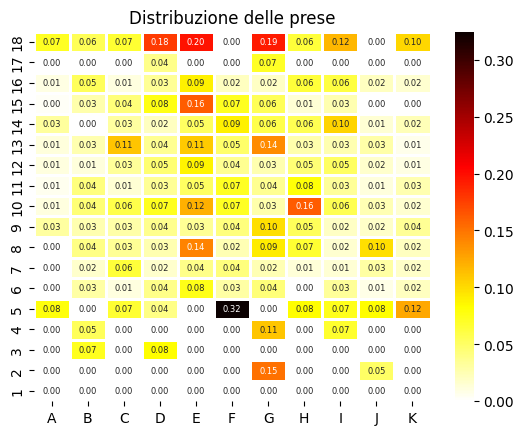

In [150]:
sns.heatmap(df_matrix, annot=True, annot_kws={"size": 6}, fmt=".2f", cbar=True, linewidths=0.8, linecolor='white', cmap="hot_r")
plt.title("Distribuzione delle prese")
plt.show()

### Frequenze relative delle prese, discriminate da grade:

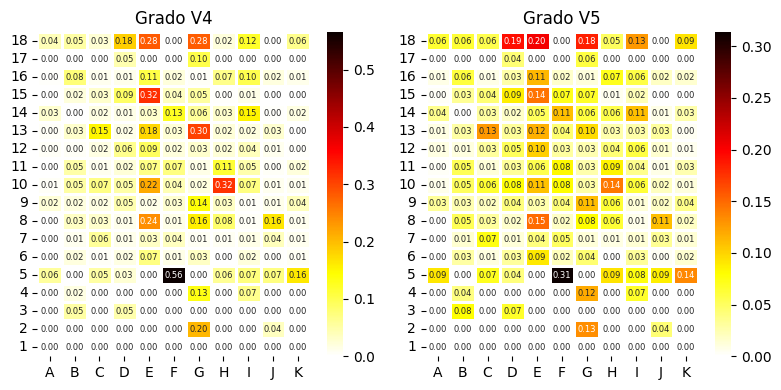

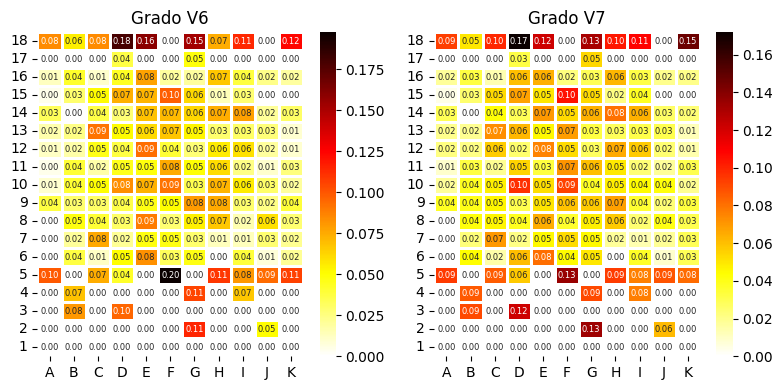

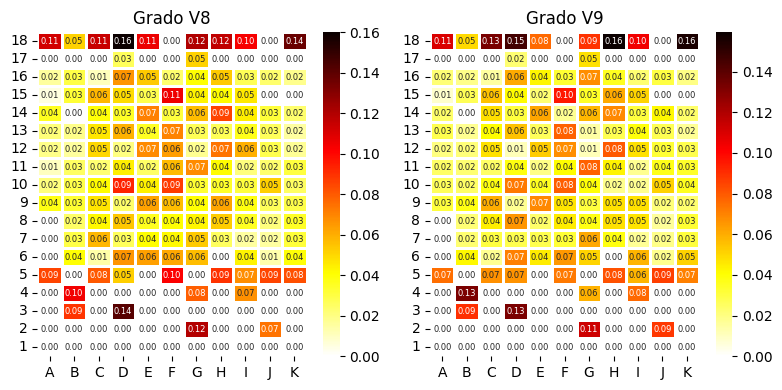

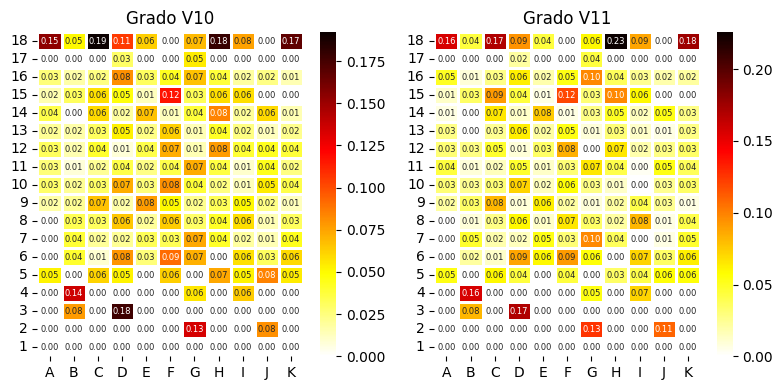

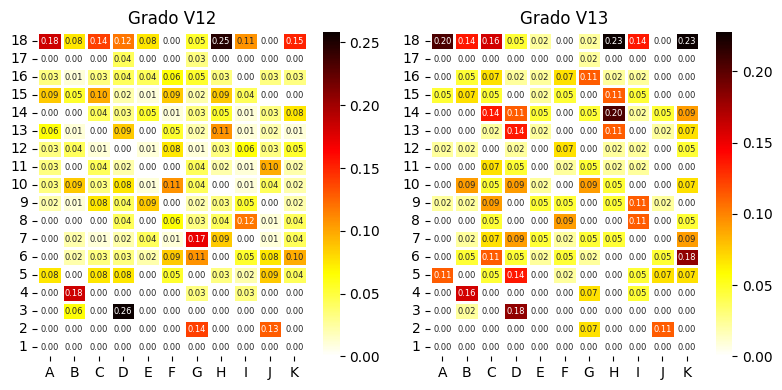

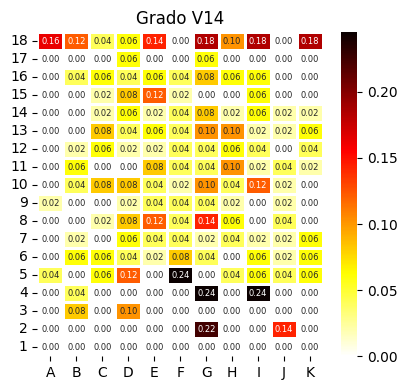

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

grade_order = [
    "6B", "6B+", "6C", "6C+", "7A", "7A+", "7B", "7B+", "7C", "7C+", "8A", "8A+", "8B", "8B+"
    ]

grade_order_v = ["V4", "V5", "V6", "V7", "V8", "V9", "V10", "V11", "V12", "V13", "V14"]

hold_columns = df_stima.loc[:, "A1":"K18"].columns
grades_to_plot = [g for g in grade_order_v if g in df_stima['grade_v'].unique()]

for i in range(0, len(grades_to_plot), 2):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for j, grade in enumerate(grades_to_plot[i:i+2]):
        df_filtered = df_stima[df_stima['grade_v'] == grade]
        # Calcola la frequenza di 1 (prese usate) per ogni colonna
        freq_ones = df_filtered[hold_columns].sum() / df_filtered.shape[0]
        freq_ones_df = pd.DataFrame([freq_ones], columns=hold_columns).round(4)
        heatmap_matrix = freq_ones_df.to_numpy().reshape(18, 11, order='F')[::-1]
        heatmap_df = pd.DataFrame(heatmap_matrix, index=range(18, 0, -1), columns=list("ABCDEFGHIJK"))
        sns.heatmap(heatmap_df, annot=True, annot_kws={"size": 6}, fmt=".2f", cbar=True,
                    linewidths=0.8, linecolor='white', cmap="hot_r", ax=axes[j])
        axes[j].set_title(f"Grado {grade}")
    if len(grades_to_plot[i:i+2]) < 2:
        fig.delaxes(axes[1])
    plt.tight_layout()
    plt.show()

In [152]:
df_stima_cleaned.head(10)

,grade,grade_v,isBenchmark,holdsets,A1,A2,A3,A4,A5,A6,...,n_clusters,mean_cluster_size,max_cluster_size,clusters_per_hold,max_density_3x3,bbox_h,bbox_w,aspect_ratio,switch_righe,switch_colonne
0,7A,V6,False,Original School Holds | Hold Set A | Hold Set B,0,0,0,0,0,0,...,6.0,1.000000,1.0,1.000000,2.0,9.0,9.0,1.000000,12.0,12.0
1,6B+,V4,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,7.0,1.142857,2.0,0.875000,2.0,11.0,10.0,0.909091,14.0,14.0
2,6B+,V4,False,Original School Holds | Hold Set A | Hold Set B,0,0,0,0,0,0,...,8.0,1.250000,3.0,0.800000,3.0,10.0,10.0,1.000000,16.0,18.0
3,6B+,V4,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,8.0,1.000000,1.0,1.000000,2.0,9.0,11.0,1.222222,13.0,16.0
4,7A+,V7,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,6.0,1.166667,2.0,0.857143,2.0,14.0,10.0,0.714286,12.0,12.0
5,7C,V9,False,Original School Holds | Hold Set A,0,0,0,0,0,0,...,5.0,1.000000,1.0,1.000000,2.0,13.0,11.0,0.846154,8.0,9.0
6,6B+,V4,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,8.0,1.000000,1.0,1.000000,2.0,14.0,10.0,0.714286,15.0,15.0
7,7A,V6,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,6.0,1.000000,1.0,1.000000,2.0,11.0,10.0,0.909091,11.0,12.0
8,6C+,V5,False,Hold Set A | Hold Set B,0,0,0,0,1,0,...,7.0,1.000000,1.0,1.000000,2.0,18.0,11.0,0.611111,12.0,12.0
9,7A+,V7,False,Original School Holds,0,0,0,0,0,0,...,7.0,1.000000,1.0,1.000000,2.0,10.0,11.0,1.100000,11.0,14.0


In [153]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_observation(df, apiId):
    relevant_columns = sorted(
        [col for col in df_stima.columns if col[0] in "ABCDEFGHIJK" and col[1:].isdigit()],
        key=lambda x: (x[0], int(x[1:]))
    )
    
    if not relevant_columns:
        print("Nessuna colonna rilevante trovata (A1-K18).")
        return

    row = df_stima[df_stima['apiId'] == apiId]
    if row.empty:
        print(f"apiId {apiId} non trovato.")
        return

    name = row['name'].values[0]

    try:
        obs = row[relevant_columns].to_numpy().reshape((11, 18))  # (Y=18, X=11)
    except ValueError as e:
        print(f"Errore durante il reshape: {e}")
        print(f"Assicurati che ci siano esattamente 198 valori (18x11) per apiId {apiId}.")
        return

    # Ruota la matrice di 90 gradi a sinistra
    obs_rotated = np.transpose(obs)[::-1]

    obs = obs_rotated

    # Definisci una mappa di colori personalizzata
    cmap = ListedColormap(["white", "black", "black", "black"])
    bounds = [0, 1, 2, 3, 4]
    norm = plt.Normalize(vmin=0, vmax=3)

    plt.figure(figsize=(6, 6))
    plt.imshow(obs, cmap=cmap, norm=norm, aspect="equal")  

    plt.yticks(ticks=np.arange(18), labels=np.arange(18, 0, -1))  # X da 'A' a 'K'
    plt.xticks(ticks=np.arange(11), labels=list("ABCDEFGHIJK"))  # Y da 18 a 1

    plt.title(f"Problem: {name}")

    plt.show()

    filtered_row = df_stima[df_stima['apiId'] == apiId]

    if not filtered_row.empty:
        print("Grade:", filtered_row['grade'].values[0])
        print("User Grade:", filtered_row['userGrade'].values[0])
        print("Repeats:", filtered_row['repeats'].values[0])
        print("SetBy:", filtered_row['setby'].values[0])
        print("Benchmark:", filtered_row['isBenchmark'].values[0])
    else:
        print("Nessuna osservazione trovata")

In [154]:
import random

def random_apiId_generator(df):
    api_ids = df_stima['apiId'].unique()

    while True:
        yield random.choice(api_ids)

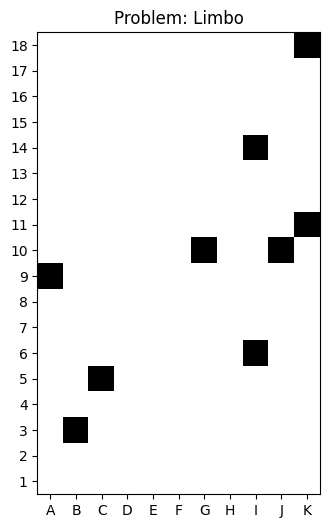

Grade: 7B
User Grade: nan
Repeats: 1
SetBy: other
Benchmark: False


In [155]:
apiId_gen = random_apiId_generator(df)
x = next(apiId_gen)
plot_observation(df_stima, apiId=x)

# STUDIO PRESE:

In [156]:
result

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,K9,K10,K11,K12,K13,K14,K15,K16,K17,K18
0,1.0,1.0,1.0,1.0,0.920826,0.999979,1.0,1.0,0.969204,0.989539,...,0.964709,0.984518,0.974162,0.990757,0.992648,0.976746,1.0,0.984119,1.0,0.897992
1,NaN,NaN,NaN,NaN,0.079174,0.000021,NaN,NaN,0.030796,0.010461,...,0.035291,0.015482,0.025838,0.009243,0.007352,0.023254,NaN,0.015881,NaN,0.102008


Cerco le prese che nel setup moonboard 2016 non vengono mai usate, se esistono

In [157]:
unique_cols = [col for col in result.columns if result[col].nunique() == 1]
print(len(unique_cols), "prese mai utilizzate:")
print("Colonne con un solo valore unico:")
print(unique_cols)

57 prese mai utilizzate:
Colonne con un solo valore unico:
['A1', 'A2', 'A3', 'A4', 'A7', 'A8', 'A17', 'B1', 'B2', 'B5', 'B14', 'B17', 'C1', 'C2', 'C3', 'C4', 'C17', 'D1', 'D2', 'D4', 'E1', 'E2', 'E3', 'E4', 'E5', 'E17', 'F1', 'F2', 'F3', 'F4', 'F17', 'F18', 'G1', 'G3', 'G5', 'H1', 'H2', 'H3', 'H4', 'H6', 'H17', 'I1', 'I2', 'I3', 'I17', 'J1', 'J3', 'J4', 'J15', 'J17', 'J18', 'K1', 'K2', 'K3', 'K4', 'K15', 'K17']


In [158]:
print(df_stima.shape)
print(df_verifica.shape)

(47604, 448)
(11902, 448)


RIMOZIONE PRESE COSTANTI

In [159]:
# Rimuovi le colonne con un solo valore unico da df_stima_cleaned
df_stima_cleaned = df_stima_cleaned.drop(columns=unique_cols)
print(f"Nuova shape df_stima_cleaned: {df_stima_cleaned.shape}")

# Rimuovi le colonne con un solo valore unico da df_verifica_cleaned
df_verifica_cleaned = df_verifica_cleaned.drop(columns=unique_cols)
print(f"Nuova shape df_verifica_cleaned: {df_verifica_cleaned.shape}") #shape conforme

Nuova shape df_stima_cleaned: (47604, 378)
Nuova shape df_verifica_cleaned: (11902, 378)


SUDDIVISIONE VARIABILI QUALITATIVE E QUANTITATIVE

In [160]:
# Suddividi le variabili in qualitative e quantitative per df_stima_cleaned
qualitative_vars = df_stima_cleaned.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
quantitative_vars = df_stima_cleaned.select_dtypes(include=["number"]).columns.tolist()
print("Qualitative vars:", qualitative_vars)
print("Quantitative vars:", quantitative_vars)

Qualitative vars: ['grade', 'grade_v', 'isBenchmark', 'holdsets']
Quantitative vars: ['A5', 'A6', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A18', 'B3', 'B4', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B15', 'B16', 'B18', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C18', 'D3', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E18', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'G2', 'G4', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'H5', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H18', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I18', 'J2', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10', 'J11', 'J12', 'J13', 'J14', 'J16', 'K5', 'K6', 'K7', 'K8', 'K9', 'K10', 'K11', 'K12', 'K13', 'K14

In [161]:
# Trasforma in qualitative tutte le quantitative con <=5 valori distinti
quantitative_to_categorical = [col for col in quantitative_vars if df_stima_cleaned[col].nunique() <= 5]
for col in quantitative_to_categorical:
    df_stima_cleaned[col] = df_stima_cleaned[col].astype(str).astype('category')
    # Aggiungi la categoria 'unknown' se non presente
    if 'unknown' not in df_stima_cleaned[col].cat.categories:
        df_stima_cleaned[col] = df_stima_cleaned[col].cat.add_categories(['unknown'])
        # (Non viene assegnato nessun valore 'unknown' ora, ma la categoria è pronta)
    
# Aggiorna gli elenchi delle variabili
qualitative_vars = df_stima_cleaned.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
quantitative_vars = df_stima_cleaned.select_dtypes(include=["number"]).columns.tolist()
print("Nuove qualitative:", qualitative_vars)
print("Nuove quantitative:", quantitative_vars)
print("Variabili convertite in qualitative:", quantitative_to_categorical)

Nuove qualitative: ['grade', 'grade_v', 'isBenchmark', 'holdsets', 'A5', 'A6', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A18', 'B3', 'B4', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B15', 'B16', 'B18', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C18', 'D3', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E18', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'G2', 'G4', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'H5', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H18', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I18', 'J2', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10', 'J11', 'J12', 'J13', 'J14', 'J16', 'K5', 'K6', 'K7', 'K8', 'K9', 'K10', 'K11', 'K12', 'K13', 'K14', 'K16', 'K18', 'd

In [162]:
# Applica la stessa trasformazione anche a df_verifica_cleaned
for col in quantitative_to_categorical:
    if col in df_verifica_cleaned.columns:
        # Converte in categoria e allinea le categorie a quelle di stima (incluso 'unknown')
        df_verifica_cleaned[col] = df_verifica_cleaned[col].astype(str).astype('category')
        df_verifica_cleaned[col] = df_verifica_cleaned[col].cat.set_categories(df_stima_cleaned[col].cat.categories)
print("Trasformazione applicata anche a df_verifica_cleaned.")

Trasformazione applicata anche a df_verifica_cleaned.


In [163]:
# Stampa le variabili che hanno almeno un valore 'unknown' in df_verifica_cleaned
cols_with_unknown = [col for col in quantitative_to_categorical if col in df_verifica_cleaned.columns and (df_verifica_cleaned[col] == 'unknown').any()]
print("Variabili con 'unknown' in verifica:", cols_with_unknown)

Variabili con 'unknown' in verifica: []


In [164]:
df_stima_cleaned.head(10)

,grade,grade_v,isBenchmark,holdsets,A5,A6,A9,A10,A11,A12,...,n_clusters,mean_cluster_size,max_cluster_size,clusters_per_hold,max_density_3x3,bbox_h,bbox_w,aspect_ratio,switch_righe,switch_colonne
0,7A,V6,False,Original School Holds | Hold Set A | Hold Set B,0,0,0,0,0,0,...,6.0,1.000000,1.0,1.000000,2.0,9.0,9.0,1.000000,12.0,12.0
1,6B+,V4,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,7.0,1.142857,2.0,0.875000,2.0,11.0,10.0,0.909091,14.0,14.0
2,6B+,V4,False,Original School Holds | Hold Set A | Hold Set B,0,0,0,0,0,0,...,8.0,1.250000,3.0,0.800000,3.0,10.0,10.0,1.000000,16.0,18.0
3,6B+,V4,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,8.0,1.000000,1.0,1.000000,2.0,9.0,11.0,1.222222,13.0,16.0
4,7A+,V7,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,6.0,1.166667,2.0,0.857143,2.0,14.0,10.0,0.714286,12.0,12.0
5,7C,V9,False,Original School Holds | Hold Set A,0,0,0,0,0,0,...,5.0,1.000000,1.0,1.000000,2.0,13.0,11.0,0.846154,8.0,9.0
6,6B+,V4,False,Hold Set A | Hold Set B,0,0,1,0,0,0,...,8.0,1.000000,1.0,1.000000,2.0,14.0,10.0,0.714286,15.0,15.0
7,7A,V6,False,Hold Set A | Hold Set B,0,0,0,0,0,0,...,6.0,1.000000,1.0,1.000000,2.0,11.0,10.0,0.909091,11.0,12.0
8,6C+,V5,False,Hold Set A | Hold Set B,1,0,0,0,0,0,...,7.0,1.000000,1.0,1.000000,2.0,18.0,11.0,0.611111,12.0,12.0
9,7A+,V7,False,Original School Holds,0,0,0,0,0,0,...,7.0,1.000000,1.0,1.000000,2.0,10.0,11.0,1.100000,11.0,14.0


In [165]:
output_path = 'C:/Users/Francesco/Documents/uni/tesi/data_expl_analysis/moon_stima.csv'
df_stima_cleaned.to_csv(output_path, index=False, encoding='utf-8')

print(f"Dataset pulito salvato in: {output_path}")

Dataset pulito salvato in: C:/Users/Francesco/Documents/uni/tesi/data_expl_analysis/moon_stima.csv


In [166]:
output_path = 'C:/Users/Francesco/Documents/uni/tesi/data_expl_analysis/moon_verifica.csv'
df_verifica_cleaned.to_csv(output_path, index=False, encoding='utf-8')

print(f"Dataset pulito salvato in: {output_path}")

Dataset pulito salvato in: C:/Users/Francesco/Documents/uni/tesi/data_expl_analysis/moon_verifica.csv
